# Enviroment and Dependencies setup

## Install Essential Dependencies

In [1]:
!pip install ml-collections

## Folder Structure setup

In [1]:
on_colab = False

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    on_colab = True
except Exception as e:
    on_colab = False

 PLEASE CHANGE THE DIRECTORY PATH ON THE BELOW CELL CORRESPONDING TO THE FOLDER CONTAIN THIS NOTEBOOK

In [2]:
# %cd "/content/drive/MyDrive/FYP/TCT code/vit-visual-search/notebooks"

## Google Colab directory setup

In [3]:
import os
import shutil

if on_colab:

    print('Notebook on Google Colab, copying files to separate directory from personal drive...')

    # _____ COPY DATASET ZIP FILE _____


    os.makedirs('/src/TCT-visual-search/datasets/SCEGRAM/', exist_ok=True)
    shutil.copyfile('../datasets/SCEGRAM/SCEGRAM-20250725T045647Z-1-001.zip', '/src/TCT-visual-search/datasets/SCEGRAM/SCEGRAM-20250725T045647Z-1-001.zip')


    print('Done copying dataset zip file!')
    # _____ COPY DATASET ZIP FILE _____



    # _____ COCO-SEARCH18 UTILS FILE _____
    # shutil.copyfile('../datasets/coco-search18/image_info.pkl', '/src/vit-visual-search/datasets/coco-search18/image_info.pkl')
    # shutil.copyfile('../datasets/coco-search18/random_filenames_pairs_0915.pkl', '/src/vit-visual-search/datasets/coco-search18/random_filenames_pairs_0915.pkl')
    # print('Done copying coco-search18 utils files')
    # _____ COCO-SEARCH18 UTILS FILE _____



    # _____ COPY CRT ATTENTION MAP _____
    # os.makedirs('/src/vit-visual-search/context/', exist_ok=True)
    # shutil.copyfile('../context/CRT_coco18test_modelmix4ZR_original_1008.pkl', '/src/vit-visual-search/context/CRT_coco18test_modelmix4ZR_original_1008.pkl')
    # shutil.copyfile('../context/CRT_naturaldesign_modelmix4ZR_original_1008.pkl', '/src/vit-visual-search/context/CRT_naturaldesign_modelmix4ZR_original_1008.pkl')
    # shutil.copyfile('../context/CRT_SCEGRAM_modelmix4ZR_original_1008.pkl', '/src/vit-visual-search/context/CRT_SCEGRAM_modelmix4ZR_original_1008.pkl')
    # print('Done copying CRT attention map files')
    # _____ COPY CRT ATTENTION MAP _____


    # ____ COPY MODEL WEIGHTS _____
    shutil.copyfile('../ViT_utils/ViT_model_weights/vitpytorch_cifar100_finetune_no_posembed.pt', '/src/TCT-visual-search/ViT_utils/ViT_model_weights/vitpytorch_cifar100_finetune_no_posembed.pt')
    print('Done copying model weights')
    # ____ COPY MODEL WEIGHTS _____
    
    root_folder = '/src'

## Local Machine directory setup

In [4]:
import os

if not on_colab:
    root_folder = '../..'


## User-defined environment variables

In [5]:
store_attn_on_local: bool = False
store_rel_on_local:  bool = True

In [6]:
if store_attn_on_local or store_rel_on_local:
    if on_colab:
        if os.path.exists('/src/TCT-visual-search/results'):
            os.unlink('/src/TCT-visual-search/results')
        os.symlink(os.path.abspath('../results'), '/src/TCT-visual-search/results')

## Environment variables setup

In [7]:
# _________ APPEND SOME PATH TO IMPORT SOME LIBRARY BELOW _____________
import sys

sys.path.append('..')
sys.path.append('../ViT_utils')

# _________ APPEND SOME PATH TO IMPORT SOME LIBRARY BELOW _____________

## Unzipping datasets files

In [8]:
import zipfile
import shutil


# Specify the path to your zip file
zip_file_path = os.path.join(
    root_folder,
    'TCT-visual-search/datasets/SCEGRAM/SCEGRAM-20250725T045647Z-1-001.zip'
)


# Specify the destination directory where you want to extract the contents
# If not provided, it extracts to the current working directory.
destination_directory = os.path.join(
    root_folder,
    'TCT-visual-search/datasets/SCEGRAM/'
)


# Create the destination directory if it doesn't exist
if not os.path.exists(destination_directory):
    os.makedirs(destination_directory)

if not os.path.exists(os.path.join(destination_directory, 'SCEGRAM')):
    print('Unzip file not found start unzipping!')

    try:
        # Open the zip file in read mode ('r')
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            # Extract all the contents to the specified destination directory
            zip_ref.extractall(destination_directory)
        print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid ZIP file.")
    except FileNotFoundError:
        print(f"Error: ZIP file '{zip_file_path}' not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
else:
    print('Unzip dataset file found!')



Unzip dataset file found!


## Importing and defining essential dependencies

## Importing essential libraries

In [9]:
import json
import numpy as np
import torch
from os.path import join
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns
from itertools import product
from PIL import Image
# import cv2
from tqdm import tqdm
import pickle
from torch.utils.data import Dataset, DataLoader

from torchvision.transforms.functional import gaussian_blur

from glob import glob


# import dataset
from tasks.visual_search2 import *

from visual_search_utils.utils import *

# from irl_dcb.utils import *
from torchvision import transforms

from visual_search_utils.data.SCEGRAM import scegram

import copy



import yaml

from CRT_utils.CRT.core.model_bbox_PE import Model

from ml_collections import ConfigDict

### Defining dataset class for CRT attention

In [33]:
import sys
import cv2
import time
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import numpy as np
import pandas as pd
import pickle
import random
import copy

from PIL import Image, ImageDraw

import torch
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor, normalize
from torchvision import transforms



target_min = 128
patch_w = 16


class scegram_crt(Dataset):
    def __init__(self, info_dir, dataset_dir, search_size, target_size, per_target=True, is_transform=True, invariant=True):
        df_info = pd.read_excel(info_dir, engine='openpyxl')
        self.df_info = df_info[df_info.obj_name != 'XXX']
        self.image_width = self.df_info.iloc[0, :]['sce_width']
        self.image_height = self.df_info.iloc[0, :]['sce_height']
        self.dataset_dir = dataset_dir
        self.search_dir = os.path.join(self.dataset_dir, "01scenes/01object_present")
        if invariant:
            self.target_dir = os.path.join(self.dataset_dir, "invariant_objects")
        else:
            self.target_dir = os.path.join(self.dataset_dir, "02objects")
        self.target_dic = {filename[3:-4]: filename for filename in os.listdir(self.target_dir)}
        self.search_size = search_size
        self.target_size = target_size if not per_target else None
        self.per_target = per_target
        self.is_transform = is_transform

        self.search_transform = transforms.Compose([
            transforms.Resize(search_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.target_transform = transforms.Compose([
            transforms.Resize(target_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ]) if not per_target else None

    def __len__(self):
        return len(self.df_info)

    def __getitem__(self, idx):
        idx_info = self.df_info.iloc[idx, :]
        search_file = os.path.join(self.search_dir, idx_info['sce_file_name'])
        target_file = os.path.join(self.target_dir, self.target_dic[idx_info['obj_name']])
        
        print(search_file)
        
        
        img_category = idx_info['sce_file_name'][:-4].split('_')[-1]

        # calculate the bounding box cordinates and the solution image
        x_center, y_center, w, h = idx_info['obj_x_center'], idx_info['obj_y_center'], idx_info['obj_width'], idx_info['obj_height']
        bbox = np.array([(x_center-0.5*w) / self.image_width * self.search_size[1],
                        (y_center-0.5*h) / self.image_height * self.search_size[0],
                        w / self.image_width * self.search_size[1],
                        h / self.image_height * self.search_size[0]]).astype(np.int32)

        solution = np.zeros(self.search_size)
        solution[bbox[1]:bbox[1]+bbox[3], bbox[0]:bbox[0]+bbox[2]] = 1

        # process search img, target img
        img = cv2.imread(search_file)
        target = cv2.imread(target_file)
        img_PIL = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        target_PIL = Image.fromarray(cv2.cvtColor(target, cv2.COLOR_BGR2RGB))

        if self.is_transform:
            # transform search image
            
            
            
            
            
            
            
            
            img = self.search_transform(img_PIL)

             # transform target image
            if not self.per_target:
                target = self.target_transform(target_PIL)
            else:
                target_w, target_h = np.array(target_PIL).shape[1], np.array(target_PIL).shape[0]
                target_max = int((target_min * max(target_w, target_h) / min(target_w, target_h)) // patch_w * patch_w)


                if target_w >= target_h:
                    target_w, target_h = target_max, target_min
                else:
                    target_h, target_w = target_max, target_min

                target_transform = transforms.Compose([
                                transforms.Resize((target_h, target_w)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                ])
                target = target_transform(target_PIL)

        search_h = self.search_size[0]
        search_w = self.search_size[1]

        bbox = torch.tensor([
            bbox[0] / search_w,
            bbox[1] / search_h,
            bbox[2] / search_w,
            bbox[3] / search_h
        ], dtype=torch.float)
        
        
        
        
        
        # _____ CRAZY EXPERIMENT _____
#         target = torch.zeros(target.shape)
        
#         x_min, y_min, w, h = bbox
#         x_min = int(x_min * 224)
#         y_min = int(y_min * 224)
#         w = int(w * 224)
#         h = int(h * 224)
        
        
        
        
#         img[:,y_min:y_min+h, x_min:x_min+w] = 0
        
        # _____ CRAZY EXPERIMENT _____
        

        return img, target, solution, bbox

### Defining utils functions

In [34]:
def get_CRT_attn(
        CRT_model      : torch.nn.Module,
        search_img     : torch.tensor,
        target_img     : torch.tensor,
        relative_bbox  : torch.tensor,
        # final_attn_size: tuple[int, int],
        attn_head_idx  : int = 4,
        device         : str = 'cpu'
) -> torch.tensor:

    search_img    = search_img.to(device)
    target_img    = target_img.to(device)
#     relative_bbox = relative_bbox.to(device)

    CRT_model.eval()
    with torch.no_grad():
        # _____ PREVIOUS VERSION _____
#         _, attention_CRTNet = CRT_model(search_img.unsqueeze(0), target_img.unsqueeze(0), relative_bbox.unsqueeze(0))

        # _____ PREVIOUS VERSION _____
        
        
        # _____ MODIFIED VERSION _____
        category, attention_CRTNet = CRT_model(
            search_img.unsqueeze(0), 
            target_img.unsqueeze(0),
            relative_bbox.unsqueeze(0)
        )
        # _____ MODIFIED VERSION _____
        
        
        print(category)
        
        
        
    attention_CRTNet = attention_CRTNet.detach().squeeze()

    attention_w = attention_h = int(np.sqrt(attention_CRTNet.shape[1]))

    attention_CRTNet = attention_CRTNet.reshape(attention_CRTNet.size(0), 7, 7)
    
#     num_attn_head = attention_CRTNet.shape[0]
    
#     final_attention = torch.tensor(np.zeros(attention_CRTNet[0].shape), dtype=torch.float).to(device)
    
#     for head_idx in range(num_attn_head):
#         final_attention += attention_CRTNet[head_idx]
        
#     final_attention /= num_attn_head
    
    # _____ PREVIOUS VERSION _____
    attention_CRTNet = copy.deepcopy(attention_CRTNet[attn_head_idx].unsqueeze(0))
    # _____ PREVIOUS VERSION _____
    

    # _____ MODIFIED VERSION _____
    
#     attention_CRTNet = copy.deepcopy(final_attention.unsqueeze(0))
    # _____ MODIFIED VERSION _____
    
    
    
    # attention_CRTNet =  transforms.Resize((final_attn_size[0], final_attn_size[1]))(attention_CRTNet.unsqueeze(0))

    return attention_CRTNet

### User-defined code variables

In [12]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps"  # macbook uses metal performance shaders to GPU accelearation
    if torch.backends.mps.is_available()
    else "cpu"
)

search_w_crt = 224
search_h_crt = 224

search_w     = 512
search_h     = 320
target_min   = 128
patch_w      = 16
patch_h      = 16

n_patch_w, n_patch_h = int(search_w // patch_w), int(search_h // patch_h)

IOR_size     = 24
dataset      = 'scegram'
n_random     = 100



dataset_dir = os.path.join(destination_directory, 'SCEGRAM')

### Loading weights for CRT and ViT model

#### CRT model

In [41]:
checkpoint = "../CRT_utils/CRT_weights_and_config/CRT_COCO_random/CRT bbox PE new json/checkpoint_215.tar"
config     = "../CRT_utils/CRT_weights_and_config/CRT_COCO_random/CRT bbox PE new json/config.yaml"

with open(config) as f:
    cfg = ConfigDict(yaml.load(f, Loader=yaml.Loader))

if not hasattr(cfg, "num_classes"):     # infer number of classes
    with open(cfg.annotations, 'rb') as f:
        NUM_CLASSES = len(json.load(f)["categories"])
    cfg.num_classes = NUM_CLASSES

checkpoint = torch.load(checkpoint, map_location="cpu")



In [42]:
crt_model = Model.from_config(cfg)

In [43]:
crt_model.load_state_dict(checkpoint['model_state_dict'])
crt_model.extended_output = True
crt_model.training        = False

#### ViT model

In [16]:
vit = load_model(device=device)

### Move both model to DEVICE

In [17]:
%%capture
crt_model.to(device)
vit.to(device)

### Set both model to EVAL

In [18]:
%%capture
crt_model.eval()
vit.eval()

# CRT Attention generation

In [28]:
def get_CRT_attn(
        CRT_model      : torch.nn.Module,
        search_img     : torch.tensor,
        target_img     : torch.tensor,
        relative_bbox  : torch.tensor,
        # final_attn_size: tuple[int, int],
        attn_head_idx  : int = 4,
        device         : str = 'cpu'
) -> torch.tensor:

    search_img    = search_img.to(device)
    target_img    = target_img.to(device)
#     relative_bbox = relative_bbox.to(device)

    CRT_model.eval()
    with torch.no_grad():
        # _____ PREVIOUS VERSION _____
#         _, attention_CRTNet = CRT_model(search_img.unsqueeze(0), target_img.unsqueeze(0), relative_bbox.unsqueeze(0))

        # _____ PREVIOUS VERSION _____
        
        
        # _____ MODIFIED VERSION _____
        _, attention_CRTNet = CRT_model(
            search_img.unsqueeze(0), 
            target_img.unsqueeze(0),
            relative_bbox.unsqueeze(0)
        )
        # _____ MODIFIED VERSION _____
        
    
    print(attention_CRTNet)
        
        
        
    attention_CRTNet = attention_CRTNet.detach().squeeze()

    attention_w = attention_h = int(np.sqrt(attention_CRTNet.shape[1]))

    attention_CRTNet = attention_CRTNet.reshape(attention_CRTNet.size(0), 7, 7)
    
#     num_attn_head = attention_CRTNet.shape[0]
    
#     final_attention = torch.tensor(np.zeros(attention_CRTNet[0].shape), dtype=torch.float).to(device)
    
#     for head_idx in range(num_attn_head):
#         final_attention += attention_CRTNet[head_idx]
        
#     final_attention /= num_attn_head
    
    # _____ PREVIOUS VERSION _____
    attention_CRTNet = copy.deepcopy(attention_CRTNet[attn_head_idx].unsqueeze(0))
    # _____ PREVIOUS VERSION _____
    

    # _____ MODIFIED VERSION _____
    
#     attention_CRTNet = copy.deepcopy(final_attention.unsqueeze(0))
    # _____ MODIFIED VERSION _____
    
    
    
    # attention_CRTNet =  transforms.Resize((final_attn_size[0], final_attn_size[1]))(attention_CRTNet.unsqueeze(0))

    return attention_CRTNet

In [30]:
s_im, t_im, solution, t_bbox = dset[10]

get_CRT_attn(
    CRT_model       = crt_model,
    search_img      = s_im,
    target_img      = t_im,
    relative_bbox   = t_bbox.to(device),
#         final_attn_size = (search_h, search_w),
    attn_head_idx   = 5,
    device          = device
)

tensor([[[[0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204]],

         [[0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
           0.0204]],

         [[0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.020

tensor([[[0.0198, 0.0200, 0.0189, 0.0183, 0.0182, 0.0182, 0.0181],
         [0.0232, 0.0246, 0.0209, 0.0189, 0.0186, 0.0184, 0.0181],
         [0.0223, 0.0245, 0.0223, 0.0200, 0.0195, 0.0191, 0.0185],
         [0.0200, 0.0222, 0.0236, 0.0232, 0.0226, 0.0222, 0.0199],
         [0.0201, 0.0220, 0.0233, 0.0236, 0.0232, 0.0221, 0.0199],
         [0.0195, 0.0206, 0.0209, 0.0208, 0.0205, 0.0201, 0.0191],
         [0.0188, 0.0190, 0.0189, 0.0186, 0.0185, 0.0183, 0.0182]]],
       device='mps:0')

In [35]:
dset_config = dict(
    dataset_dir  = dataset_dir,
    info_dir     = os.path.join(dataset_dir, 'SCEGRAM_Database_scenes_objects.xlsx'),
    search_size  = (search_h_crt, search_w_crt),
    target_size  = (search_h_crt, search_w_crt),
    per_target   = False,
    is_transform = True
)

dset = scegram_crt(**dset_config)

In [44]:
s_im, t_im, solution, t_bbox = dset[0]


get_CRT_attn(
    CRT_model       = crt_model,
    search_img      = s_im,
    target_img      = t_im,
    relative_bbox   = t_bbox.to(device),
#         final_attn_size = (search_h, search_w),
    attn_head_idx   = 5,
    device          = device
)

../../TCT-visual-search/datasets/SCEGRAM/SCEGRAM/01scenes/01object_present/Scene1_CON.png


RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

In [19]:


crt_attn = {}



dset_config = dict(
    dataset_dir  = dataset_dir,
    info_dir     = os.path.join(dataset_dir, 'SCEGRAM_Database_scenes_objects.xlsx'),
    search_size  = (search_h_crt, search_w_crt),
    target_size  = (search_h_crt, search_w_crt),
    per_target   = False,
    is_transform = True
)

dset = scegram_crt(**dset_config)
idx_info = dset.df_info.iloc

for i in trange(len(dset)):

    # name = dset.image_info[dset.task]['names'][i]
    key = idx_info[i, :]['sce_file_name']


    s_im, t_im, solution, t_bbox = dset[i]

    crt_attn[key] = get_CRT_attn(
        CRT_model       = crt_model,
        search_img      = s_im,
        target_img      = t_im,
        relative_bbox   = t_bbox.to(device),
#         final_attn_size = (search_h, search_w),
        attn_head_idx   = 0,
        device          = device
    )



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:34<00:00, 10.69it/s]


# TCT Model

In [22]:
# _____ EXPERIMENT PARAMETER _____
is_gaussian_blur = True 


# _____ EXPERIMENT PARAMETER _____


dset_config = dict(
    info_dir     = os.path.join(dataset_dir, 'SCEGRAM_Database_scenes_objects.xlsx'),
    dataset_dir  = dataset_dir,
    search_size  = (search_h, search_w),
    target_size  = (0, 0),
    per_target   = True,
    is_transform = True
)

dset = scegram(**dset_config)

result = dict()

for i in tqdm(range(len(dset))):
    vit.to(device)

    key         = idx_info[i, :]['sce_file_name']
    result[key] = dict()
    temp        = result[key]

    s_im, t_im, solution, t_bbox, _ = dset.__getitem__(i)

    # Task 0: random search
    rands = []
    for n in range(n_random):
        np.random.seed(int(i + 1e3 + n))
        rand_attn     = np.random.rand(search_h, search_w)
        attn          = add_init_fix(rand_attn, search_w, search_h)
        rand_path_rel = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
        rands.append(rand_path_rel)

    temp['rand_path_rel'] = rands

    # Task 1: CRT alone
    crt_tensor      = crt_attn[key]
    
    
    
    
    
    
    
    
    
    
    norm_crt_tensor = crt_tensor / crt_tensor.max()
    
    
    
    # _____ TRY HEAVILY SMOOTH THE CRT _____
    
    if is_gaussian_blur:
        norm_crt_relevance = transforms.Resize((search_h, search_w))(norm_crt_tensor).cpu()
        norm_crt_relevance = gaussian_blur(norm_crt_relevance, kernel_size=13, sigma=2).squeeze().numpy()
    
    
    # _____ TRY HEAVILY SMOOTH THE CRT _____
    
    
    else:
    
    #         norm_crt_tensor = (crt_tensor - crt_tensor.min()) / (crt_tensor.max() - crt_tensor.min()) # normalize
        norm_crt_relevance = transforms.Resize((search_h, search_w))(norm_crt_tensor).cpu().squeeze().numpy()
    
    
    attn               = add_init_fix(norm_crt_relevance, search_w, search_h)
    
    
    
    
    
    crt_path_rel       = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
    temp['crt_alone_path_rel'] = crt_path_rel

    # normalized CRT relevance tensor
    crt_tensor = transforms.Resize((n_patch_h, n_patch_w))(norm_crt_tensor).squeeze().reshape(-1).to(device)
    crt_tensor = (crt_tensor - crt_tensor.mean()) / crt_tensor.std() * 100
    crt_tensor = torch.sigmoid(crt_tensor)

    for crt in ['global_3']:
        # Task 2: VIT local modulation alone
        if crt is None:
            flag                  = ''
            crt_mod_method        = None
            crt_global_mod_layers = []
            crt_global_mod        = None
            crt_local_mod         = None

        # Task 3: Integrated CRT global & VIT local
        elif 'global' in crt:
            flag = 'crt_{}_'.format(crt)
            crt_mod_method = 5
            layer = eval(crt.split('_')[1])-1 # Layer 2
            crt_global_mod_layers = [layer]
            crt_global_mod = crt_tensor
            crt_local_mod = None

        attns, paths, product_attns, product_paths, sum_attns, sum_paths = [], [], [], [], [], []


        for n in [7]:
            target_embedding = None

            mod_attn = get_attn(
                vit,
                s_im,
                crt_mod_method=crt_mod_method,
                crt_global_mod_layers=crt_global_mod_layers,
                crt_global_mod=crt_global_mod,
                crt_local_mod=crt_local_mod,
                mod_last_n=n,
                t_im=t_im,
                target_embedding=target_embedding,
                mod='relevance',
                processed=True,
                device=device
            )

            attn = add_init_fix(mod_attn, search_w, search_h)
            path = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
            attns.append(mod_attn)
            paths.append(path)

            if crt is None:
                # Task 5: product of crt clone and vit alone
                product_attn = mod_attn * norm_crt_relevance
                attn = add_init_fix(product_attn, search_w, search_h)
                path = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
                product_attns.append(product_attn)
                product_paths.append(path)

                # Task 6:sum of crt clone and vit alone
                norm_mod_attn = (mod_attn - mod_attn.min()) / (mod_attn.max() - mod_attn.min())
                sum_attn = norm_mod_attn + norm_crt_relevance
                attn = add_init_fix(sum_attn, search_w, search_h)
                path = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
                sum_attns.append(sum_attn)
                sum_paths.append(path)

        temp['{}mod_attns'.format(flag)] = np.stack(attns)
        temp['{}paths_rel'.format(flag)] = paths

        if crt is None:
            temp['product_mod_attns'.format(flag)] = np.stack(product_attns)
            temp['product_paths_rel'.format(flag)] = product_paths
            temp['sum_mod_attns'.format(flag)] = np.stack(sum_attns)
            temp['sum_paths_rel'.format(flag)] = sum_paths

            # Task 4: unmodulated VIT
            unmod_attn = get_attn(
                vit,
                s_im,
                crt_mod_method=crt_mod_method,
                crt_global_mod_layers=crt_global_mod_layers,
                crt_global_mod=crt_global_mod,
                crt_local_mod=crt_local_mod,
                processed=True,
                device=device)


            attn = add_init_fix(unmod_attn, search_w, search_h)
            unmod_path_rel = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
            temp['unmod_attn'] = unmod_attn
            temp['unmod_path_rel'] = unmod_path_rel


result_keys = result.keys()

if store_attn_on_local or store_rel_on_local:

    save_result = dict()

    for key in result_keys:
        save_result[key] = dict()

        result_key_keys = result[key].keys()

        for key_key in result_key_keys:
            if ('attn' in key_key) and store_attn_on_local:
                save_result[key][key_key] = copy.deepcopy(result[key][key_key])
            elif ('path' in key_key) and store_rel_on_local:
                save_result[key][key_key] = copy.deepcopy(result[key][key_key])
                
                
    

    with open(
        os.path.join(
            root_folder,
            'TCT-visual-search/results/NGTU1[SCEGRAM_invariant]_modelZRMIX4_with_sigmoid_results_mod67.pkl'
        ), 'wb') as handle:
        pickle.dump(save_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

    del save_result

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 372/372 [14:51<00:00,  2.40s/it]


In [20]:
list(crt_attn.keys())[0]

'Scene1_CON.png'

In [32]:
crt_tensor = crt_attn['Scene4_SYN.png']
crt_tensor

tensor([[[0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204]]],
       device='mps:0')

In [23]:
norm_crt_tensor = crt_tensor / crt_tensor.max()
norm_crt_tensor

tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]]],
       device='mps:0')

../../TCT-visual-search/datasets/SCEGRAM/SCEGRAM/01scenes/01object_present/Scene1_CON.png


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


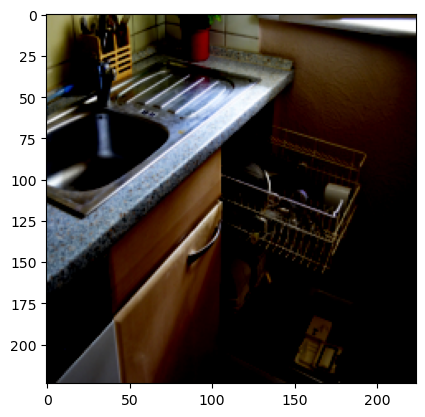

In [38]:


s_im, t_im, solution, t_bbox = dset[0]

plt.imshow(s_im.permute(1, 2,0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


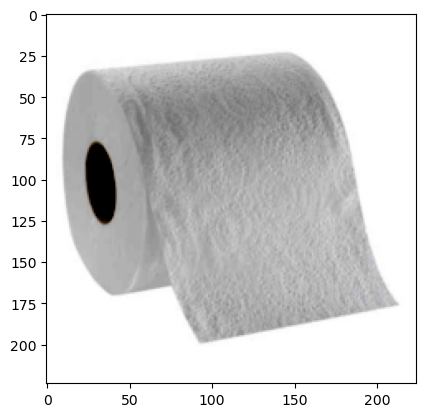

In [31]:
plt.imshow(t_im.permute(1, 2,0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


11 43 36 51


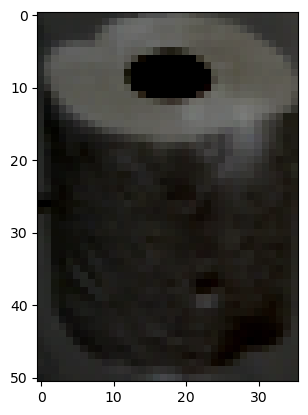

In [32]:
x_min, y_min, w, h = t_bbox
x_min = int(x_min * 224)
y_min = int(y_min * 224)
w = int(w * 224)
h = int(h * 224)

print(x_min, y_min, w, h)
plt.imshow(s_im[:,y_min:y_min+h, x_min:x_min+w].permute(1, 2,0))

In [51]:
x_min

tensor(167.)

In [26]:

get_CRT_attn(
    CRT_model       = crt_model,
    search_img      = s_im,
    target_img      = t_im,
    relative_bbox   = t_bbox.to(device),
#         final_attn_size = (search_h, search_w),
    attn_head_idx   = 0,
    device          = device
)

tensor([[[0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204],
         [0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204]]],
       device='mps:0')

In [23]:
labels = ['TCT SCEGRAM', 'Random']

fix_method = 'rel'
max_steps = 20
# mod_last_n = 7

# We mod last 7 layers but we just use 1 loop so we just have a dummy variable here to select the layer
mod_last_n = 0

all_cdfs = []




dset_config = dict(
    info_dir     = os.path.join(dataset_dir, 'SCEGRAM_Database_scenes_objects.xlsx'),
    dataset_dir  = dataset_dir,
    search_size  = (search_h, search_w),
    target_size  = (0, 0),
    per_target   = True,
    is_transform = True
)

dset = scegram(**dset_config)

# result = dict()

cdfs = []
# crts, unmods, vits, sums, products, globals, randoms = [], [], [], [], [], [], []

globals, randoms = [], []

for i in range(len(dset)):
    # name = dset.image_info[dset.task]['names'][i]
    # key = task + '_' + name
    key = idx_info[i, :]['sce_file_name']

    dic = result[key]
    # unmods.append(dic['unmod_path_rel'])
    # vits.append(dic['paths_{}'.format(fix_method)][mod_last_n-1])
    # crts.append(dic['crt_alone_path_{}'.format(fix_method)])
    # sums.append(dic['sum_paths_{}'.format(fix_method)][mod_last_n-1])
    # products.append(dic['product_paths_{}'.format(fix_method)][mod_last_n-1])
    globals.append(dic['crt_global_3_paths_{}'.format(fix_method)][mod_last_n-1])
    randoms.extend(dic['rand_path_{}'.format(fix_method)])

# for paths in [crts, unmods, vits, sums, products, globals, randoms]:
#     cdfs.append(get_cdf(paths, max_steps))


for paths in [globals, randoms]:
    cdfs.append(get_cdf(paths, max_steps))


all_cdfs.append(cdfs)

# _____ REMOVE THESE LINES AFTER DEBUGGING _____
# break
# _____ REMOVE THESE LINES AFTER DEBUGGING _____

avg_cdfs = np.stack(all_cdfs).mean(0)
std_cdfs = np.stack(all_cdfs).std(0)

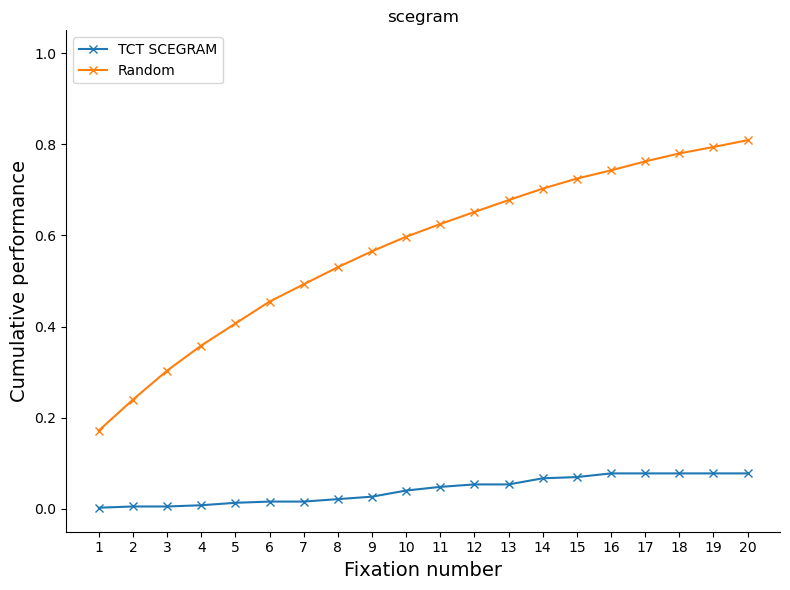

In [24]:
plt.figure(figsize=(8, 6), dpi=100)

for mean, label in zip(avg_cdfs, labels):
    plt.plot(np.arange(1, 21), mean, label=label, marker='x')

plt.xticks(range(1, 21))
plt.ylim([-0.05, 1.05])
plt.legend()
plt.xlabel('Fixation number', fontsize=14)
plt.ylabel('Cumulative performance', fontsize=14)
plt.title(dataset)
plt.legend(loc=2)
sns.despine()
plt.tight_layout()

In [48]:
TCT_coco_performance = {
    'TCT': avg_cdfs[0]
}

In [25]:
with open(os.path.join(root_folder, 'TCT-visual-search/results/NGTU1[SCEGRAM]performance.pkl'), 'wb') as handle:
            pickle.dump(TCT_coco_performance, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [26]:
TCT_coco_performance = {
    'TCT': avg_cdfs[1]
}

In [27]:
with open(os.path.join(root_folder, 'TCT-visual-search/results/NGTU1[SCEGRAM_RANDOM]performance.pkl'), 'wb') as handle:
            pickle.dump(TCT_coco_performance, handle, protocol=pickle.HIGHEST_PROTOCOL)